# 1. Load libraries

We first load the basic Python, PyTorch, and visualization libraries.

For this notebook, the main objects we need are two augmented views of the same input:

$$
x_i \rightarrow x_i^{(1)}, x_i^{(2)}
$$

The encoder maps each view to a representation:

$$
h = f_\theta(x)
$$

This is the representation we keep after training.

Then a projection head maps the representation to the contrastive space:

$$
z = g_\phi(h)
$$

The contrastive loss is applied to \(z\), but downstream evaluation uses \(h\).

We also set the random seed and choose the available device.

In [1]:
# ============================================================
# 1. Load libraries
# ============================================================

from pathlib import Path
import random
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T
from torchvision.datasets import CIFAR10

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from pathlib import Path

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
def set_seed(seed: int = 7) -> None:
    """
    Set random seeds for reproducible experiments.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------
# Device helper
# ------------------------------------------------------------
def get_device() -> torch.device:
    """
    Choose the best available device.
    Priority:
        CUDA GPU > Apple Silicon MPS > CPU
    """
    if torch.cuda.is_available():
        return torch.device("cuda")

    if torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")


set_seed(7)
device = get_device()

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", device)

PyTorch version: 2.3.1
Torchvision version: 0.18.1
Device: cuda


# 2. Load the dataset

We use CIFAR-10 as an unlabeled dataset for contrastive training.

During training, we only use the images:

$$
\mathcal{D} = \{x_i\}_{i=1}^{N}
$$

The class labels are **not used** to train the contrastive model.

Later, after training, we will use the labels only for evaluation:

$$
h = f_\theta(x)
\rightarrow
\text{kNN / linear probe}
$$

This lets us ask whether the self-supervised representation \(h\) organizes images by semantic class.

In [2]:
# ============================================================
# 2. Load the dataset
# ============================================================

DATA_DIR = Path("./data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# For now, use a minimal transform.
# Strong contrastive augmentations will be defined in the next section.
base_transform = T.Compose([
    T.ToTensor(),
])

train_base = CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=base_transform,
)

test_base = CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=base_transform,
)

print("Number of training images:", len(train_base))
print("Number of test images:", len(test_base))

# Inspect one example.
x0, y0 = train_base[0]

print("Image tensor shape:", x0.shape)
print("Label exists but will not be used for contrastive training:", y0)

Files already downloaded and verified
Files already downloaded and verified
Number of training images: 50000
Number of test images: 10000
Image tensor shape: torch.Size([3, 32, 32])
Label exists but will not be used for contrastive training: 6


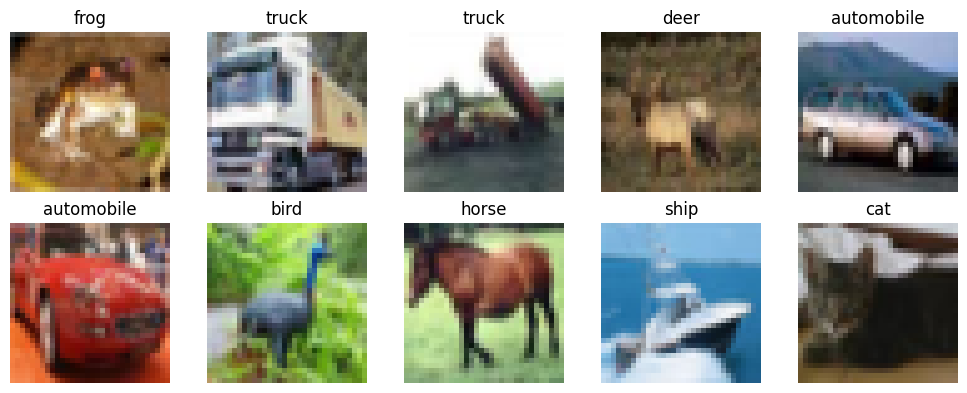

In [3]:
# ============================================================
# Visualize a few CIFAR-10 images
# ============================================================

class_names = train_base.classes

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for k in range(10):
    x, y = train_base[k]

    # x is [C, H, W]; matplotlib expects [H, W, C]
    img = x.permute(1, 2, 0).numpy()

    axes[k].imshow(img)
    axes[k].set_title(class_names[y])
    axes[k].axis("off")

plt.tight_layout()
plt.show()

# 3. Define augmentation functions

Contrastive learning creates its own supervision by making different views of the same input.

For each image \(x_i\), we sample transformations from an augmentation family:

$$
T_a \sim \mathcal{T}
$$

and create an augmented view:

$$
x_i^{(a)} = T_a(x_i)
$$

For CIFAR-10, common image augmentations are random crop, horizontal flip, color jitter, grayscale, and normalization.

The augmentation choice matters because it defines what the representation should ignore.

For example, if two views of the same image have different color statistics, the model is encouraged to learn a representation that is less sensitive to color changes.

In [4]:
# ============================================================
# 3. Define augmentation functions
# ============================================================

# CIFAR-10 channel statistics.
# These are used to normalize images before passing them to the model.
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2470, 0.2435, 0.2616)


# ------------------------------------------------------------
# Contrastive augmentation transform
# ------------------------------------------------------------
# This is a SimCLR-style image augmentation pipeline.
#
# It creates different views of the same image by applying random
# crop, flip, color distortion, and grayscale conversion.
#
# Important:
# labels are not used here. The supervision comes from the fact that
# two transformed views came from the same original image.
contrastive_transform = T.Compose([
    T.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([
        T.ColorJitter(
            brightness=0.4,
            contrast=0.4,
            saturation=0.4,
            hue=0.1,
        )
    ], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.ToTensor(),
    T.Normalize(mean=cifar_mean, std=cifar_std),
])


# ------------------------------------------------------------
# Evaluation transform
# ------------------------------------------------------------
# This transform is deterministic.
# We use it later when extracting representations for evaluation.
eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=cifar_mean, std=cifar_std),
])


# ------------------------------------------------------------
# Optional weaker augmentation transform
# ------------------------------------------------------------
# This is useful for comparison later.
# It changes the image less aggressively than the main contrastive transform.
weak_contrastive_transform = T.Compose([
    T.RandomResizedCrop(size=32, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=cifar_mean, std=cifar_std),
])


# ------------------------------------------------------------
# Helper: undo normalization for visualization
# ------------------------------------------------------------
def unnormalize_cifar(x: torch.Tensor) -> torch.Tensor:
    """
    Undo CIFAR-10 normalization for visualization.

    Input:
        x: tensor with shape [3, 32, 32]

    Output:
        x_vis: tensor with values clipped to [0, 1]
    """
    mean = torch.tensor(cifar_mean).view(3, 1, 1)
    std = torch.tensor(cifar_std).view(3, 1, 1)

    x_vis = x.cpu() * std + mean
    x_vis = torch.clamp(x_vis, 0.0, 1.0)

    return x_vis


# ------------------------------------------------------------
# Visualize multiple augmented views of one image
# ------------------------------------------------------------
def show_augmented_views(dataset, index: int = 0, n_views: int = 8, transform=None) -> None:
    """
    Show multiple augmented views of one CIFAR-10 image.

    dataset:
        A CIFAR-10 dataset with transform=None, so it returns PIL images.

    index:
        Which image to visualize.

    n_views:
        Number of augmented views to generate.

    transform:
        Augmentation pipeline to apply.
    """
    if transform is None:
        raise ValueError("Please provide an augmentation transform.")

    x_pil, y = dataset[index]

    fig, axes = plt.subplots(1, n_views + 1, figsize=(1.7 * (n_views + 1), 2.2))

    axes[0].imshow(x_pil)
    axes[0].set_title(f"original\n{dataset.classes[y]}")
    axes[0].axis("off")

    for k in range(n_views):
        x_aug = transform(x_pil)
        x_aug_vis = unnormalize_cifar(x_aug)
        img = x_aug_vis.permute(1, 2, 0).numpy()

        axes[k + 1].imshow(img)
        axes[k + 1].set_title(f"view {k + 1}")
        axes[k + 1].axis("off")

    plt.tight_layout()
    plt.show()

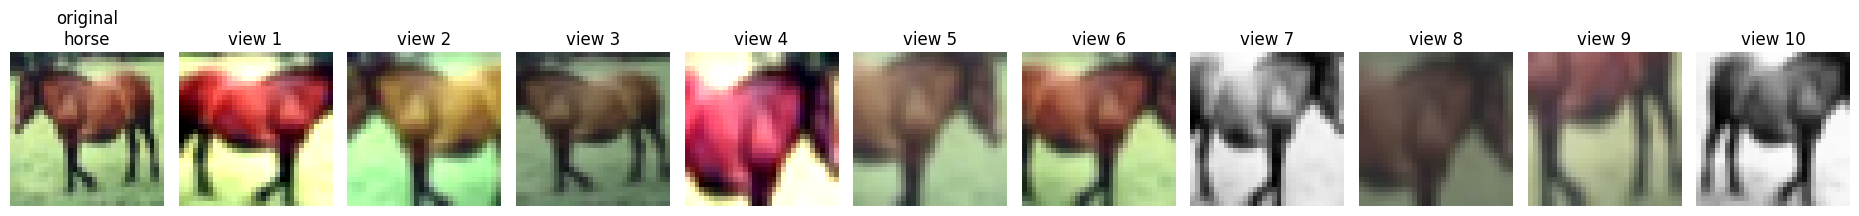

In [5]:
# Raw CIFAR-10 dataset for visualization only.
# We keep transform=None so augmentation functions receive the original PIL image.
train_raw = CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=None,
)

show_augmented_views(
    dataset=train_raw,
    index=7,
    n_views=10,
    transform=contrastive_transform,
)

# 4. Create multiple views per input

For each original image \(x_i\), contrastive learning creates two augmented views:

$$
x_i^{(1)} = T_1(x_i)
$$

$$
x_i^{(2)} = T_2(x_i)
$$

These two views are treated as different observations of the same underlying image.

In this notebook, we use the standard SimCLR-style setting:

$$
V_B = 2
$$

two views per image per batch.

In [6]:
# ============================================================
# 4. Create multiple views per input
# ============================================================

class TwoViewTransform:
    """
    Apply the same augmentation pipeline twice to one input image.

    Input:
        x: one original image, usually a PIL image from CIFAR-10

    Output:
        x1: first augmented view
        x2: second augmented view
    """

    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        x1 = self.transform(x)
        x2 = self.transform(x)
        return x1, x2


# ------------------------------------------------------------
# CIFAR-10 dataset for contrastive training
# ------------------------------------------------------------
# This dataset returns:
#
#     ((x_i^(1), x_i^(2)), label)
#
# The label is returned by CIFAR-10, but we will ignore it during
# contrastive training.
# ------------------------------------------------------------

train_contrastive = CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=TwoViewTransform(contrastive_transform),
)


# ------------------------------------------------------------
# Inspect one sample
# ------------------------------------------------------------

(x1, x2), y = train_contrastive[0]

print("View 1 shape:", x1.shape)
print("View 2 shape:", x2.shape)
print("Label exists but is not used for contrastive training:", y)


# ------------------------------------------------------------
# Visualize two augmented views of the same image
# ------------------------------------------------------------

def show_two_views(dataset, index: int = 0) -> None:
    """
    Visualize the two augmented views returned by the contrastive dataset.
    """

    (x1, x2), y = dataset[index]

    x1_vis = unnormalize_cifar(x1)
    x2_vis = unnormalize_cifar(x2)

    fig, axes = plt.subplots(1, 2, figsize=(4, 2.2))

    axes[0].imshow(x1_vis.permute(1, 2, 0).numpy())
    axes[0].set_title(r"$x_i^{(1)}$")
    axes[0].axis("off")

    axes[1].imshow(x2_vis.permute(1, 2, 0).numpy())
    axes[1].set_title(r"$x_i^{(2)}$")
    axes[1].axis("off")

    plt.suptitle("Two augmented views of the same image")
    plt.tight_layout()
    plt.show()

View 1 shape: torch.Size([3, 32, 32])
View 2 shape: torch.Size([3, 32, 32])
Label exists but is not used for contrastive training: 6


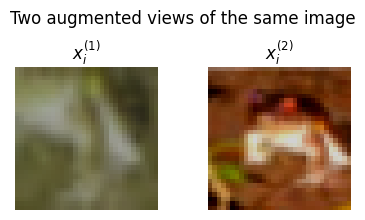

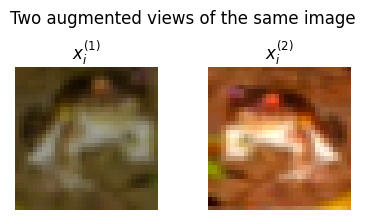

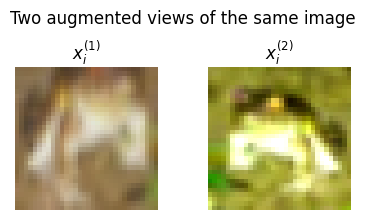

In [7]:
show_two_views(train_contrastive, index=0)
show_two_views(train_contrastive, index=0)
show_two_views(train_contrastive, index=0)

# 5. Define positives and negatives

Now we define the learning signal created by the augmented views.

For one input image:

$$
x_i
$$

we created two augmented views:

$$
x_i^{(1)}, \quad x_i^{(2)}
$$

These two views come from the same original image, so they are a **positive pair**:

$$
x_i^{(1)} \sim x_i^{(2)}
$$

Views from different original images are treated as **negative pairs**:

$$
x_i^{(a)} \not\sim x_j^{(c)}, \qquad j \neq i
$$

So the contrastive task is:

$$
\text{same input} \rightarrow \text{close representation}
$$

$$
\text{different inputs} \rightarrow \text{separated representation}
$$

Later, inside each batch, the positive pair is identified using the sample index.  
All other views in the batch are treated as negatives.

In [8]:
# ============================================================
# 5. Define positives and negatives
# ============================================================

def show_positive_and_negative_views(dataset, anchor_index: int = 0, negative_indices=(1, 2, 3)) -> None:
    """
    Visualize the contrastive learning idea.

    For anchor_index:
        x_i^(1) = anchor view
        x_i^(2) = positive view

    For negative_indices:
        x_j^(1), x_j^(2), j != i = negative views

    This is only for visualization.
    The actual positive/negative structure will be handled inside the loss.
    """

    # Get anchor and positive views from the same original image.
    (anchor_view, positive_view), anchor_label = dataset[anchor_index]

    images = [anchor_view, positive_view]
    titles = [
        r"anchor: $x_i^{(1)}$",
        r"positive: $x_i^{(2)}$",
    ]

    # Get negative views from different original images.
    for neg_idx in negative_indices:
        (neg_view_1, neg_view_2), neg_label = dataset[neg_idx]

        images.append(neg_view_1)
        titles.append(r"negative: $x_j^{(1)}$")

    n_images = len(images)

    fig, axes = plt.subplots(1, n_images, figsize=(2.2 * n_images, 2.5))

    if n_images == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        img_vis = unnormalize_cifar(img)
        ax.imshow(img_vis.permute(1, 2, 0).numpy())
        ax.set_title(title)
        ax.axis("off")

    plt.suptitle("Positive and negative examples for one anchor")
    plt.tight_layout()
    plt.show()

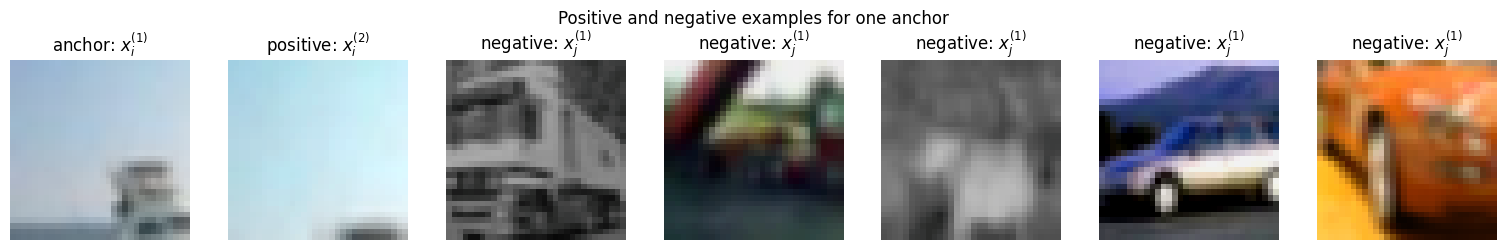

In [9]:

show_positive_and_negative_views(
    dataset=train_contrastive,
    anchor_index=100,
    negative_indices=(1, 2, 3, 4,5),
)

# 6. Build an encoder

Now we build the encoder network.

The encoder maps each augmented view to a representation:

$$
h_i^{(a)} = f_\theta(x_i^{(a)})
$$

Here \(h_i^{(a)}\) is the representation we want to keep after contrastive training.

Later, we will add a projection head:

$$
z_i^{(a)} = g_\phi(h_i^{(a)})
$$

The contrastive loss will be applied to \(z\), but downstream evaluation will use \(h\).

For CIFAR-10, we use a small convolutional encoder:

$$
x_i^{(a)}
\rightarrow
\text{Conv layers}
\rightarrow
\text{Global pooling}
\rightarrow
h_i^{(a)}
$$

In [10]:
# ============================================================
# 6. Build an encoder
# ============================================================

class SmallCIFAREncoder(nn.Module):
    """
    Small convolutional encoder for CIFAR-10 images.

    Input:
        x: [B, 3, 32, 32]

    Output:
        h: [B, h_dim]

    Here h is the representation we want to keep after training.
    """

    def __init__(self, h_dim: int = 128):
        super().__init__()

        self.features = nn.Sequential(
            # [B, 3, 32, 32] -> [B, 64, 32, 32]
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # [B, 64, 32, 32] -> [B, 64, 32, 32]
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # [B, 64, 32, 32] -> [B, 64, 16, 16]
            nn.MaxPool2d(kernel_size=2),

            # [B, 64, 16, 16] -> [B, 128, 16, 16]
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # [B, 128, 16, 16] -> [B, 128, 16, 16]
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # [B, 128, 16, 16] -> [B, 128, 8, 8]
            nn.MaxPool2d(kernel_size=2),

            # [B, 128, 8, 8] -> [B, 256, 8, 8]
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # [B, 256, 8, 8] -> [B, 256, 1, 1]
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fc = nn.Linear(256, h_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Input:
            x: [B, 3, 32, 32]

        Output:
            h: [B, h_dim]
        """
        x = self.features(x)
        x = x.flatten(start_dim=1)
        h = self.fc(x)
        return h

In [11]:
#------------------------------------------------------------Test the encoder on one contrastive batch# ------------------------------------------------------------
h_dim = 64
encoder = SmallCIFAREncoder(h_dim=h_dim).to(device)

# Get one sample from the contrastive dataset.
(x1, x2), _ = train_contrastive[0]

# Add batch dimension: [3, 32, 32] -> [1, 3, 32, 32]
x1_batch = x1.unsqueeze(0).to(device)

# Encode one view.
with torch.no_grad():
    h1 = encoder(x1_batch)

print("Input view shape:", x1_batch.shape)
print("Representation h shape:", h1.shape)
print("h_dim:", h_dim)

Input view shape: torch.Size([1, 3, 32, 32])
Representation h shape: torch.Size([1, 64])
h_dim: 64


# 7. Add a projection head - the. put together the model

The encoder gives the representation we want to keep:

$$
h_i^{(a)} = f_\theta(x_i^{(a)})
$$

Before applying the contrastive loss, we pass \(h_i^{(a)}\) through a projection head:

$$
z_i^{(a)} = g_\phi(h_i^{(a)})
$$

The contrastive loss is applied to \(z\), not directly to \(h\).

The projection head is usually a linear layer or a small MLP.

After training, we usually discard the projection head \(g_\phi\) and keep the encoder \(f_\theta\).

The full architecture is:

$$
x_i^{(a)}
\rightarrow
f_\theta
\rightarrow
h_i^{(a)}
\rightarrow
g_\phi
\rightarrow
z_i^{(a)}
$$

where:

$$
h_i^{(a)} = \text{representation kept for evaluation}
$$

and

$$
z_i^{(a)} = \text{projection used for contrastive loss}
$$

In [12]:
# ============================================================
# 7. Add a projection head
# ============================================================

class ProjectionHead(nn.Module):
    """
    Small MLP projection head.

    Input:
        h: [B, h_dim]

    Output:
        z: [B, z_dim]

    The contrastive loss will be applied to z.
    The representation h is kept for downstream evaluation.
    """

    def __init__(self, h_dim: int = 128, z_dim: int = 64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(h_dim, h_dim),
            nn.ReLU(inplace=True),
            nn.Linear(h_dim, z_dim),
        )

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        z = self.net(h)
        return z


class SimCLRModel(nn.Module):
    """
    Encoder + projection head.

    Architecture:

        x -> encoder f_theta -> h -> projector g_phi -> z

    h is the representation we keep.
    z is used for the contrastive loss.
    """

    def __init__(self, h_dim: int = 128, z_dim: int = 64):
        super().__init__()

        self.encoder = SmallCIFAREncoder(h_dim=h_dim)
        self.projector = ProjectionHead(h_dim=h_dim, z_dim=z_dim)

    def forward(self, x: torch.Tensor):
        """
        Input:
            x: [B, 3, 32, 32]

        Output:
            h: [B, h_dim]
            z: [B, z_dim]
        """
        h = self.encoder(x)
        z = self.projector(h)

        return h, z

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """
        Return only the encoder representation h.

        This is what we use after training for evaluation.
        """
        h = self.encoder(x)
        return h


In [13]:

# ------------------------------------------------------------
# Test the full model on one view
# ------------------------------------------------------------

h_dim = 3
z_dim = 3

model = SimCLRModel(h_dim=h_dim, z_dim=z_dim).to(device)

# Get one augmented view from the contrastive dataset.
(x1, x2), _ = train_contrastive[0]

# Add batch dimension.
x1_batch = x1.unsqueeze(0).to(device)

with torch.no_grad():
    h1, z1 = model(x1_batch)

print("Input shape:", x1_batch.shape)
print("Encoder representation h shape:", h1.shape)
print("Projection z shape:", z1.shape)
print("h_dim:", h_dim)
print("z_dim:", z_dim)

Input shape: torch.Size([1, 3, 32, 32])
Encoder representation h shape: torch.Size([1, 3])
Projection z shape: torch.Size([1, 3])
h_dim: 3
z_dim: 3


# 8. Define similarity

The contrastive loss compares projected representations:

$$
z_i^{(a)} = g_\phi(h_i^{(a)})
$$

A common choice is cosine similarity:

$$
\mathrm{sim}(u,v)
=
\frac{u^\top v}{\|u\|_2 \|v\|_2}
$$

In practice, we usually normalize the projected vectors:

$$
\bar{z}
=
\frac{z}{\|z\|_2}
$$

Then cosine similarity becomes a dot product:

$$
\mathrm{sim}(u,v)
=
\bar{u}^{\top}\bar{v}
$$

For a batch of projected vectors:

$$
Z =
\begin{bmatrix}
z_1 \\
z_2 \\
\vdots \\
z_M
\end{bmatrix}
$$

we can compute all pairwise similarities at once:

$$
S = \bar{Z}\bar{Z}^{\top}
$$

where \(S_{pq}\) is the cosine similarity between projected vectors \(z_p\) and \(z_q\).

In [14]:
# ============================================================
# 8. Define similarity
# ============================================================

def normalize_embeddings(z: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    L2-normalize embeddings along the feature dimension.

    Input:
        z: [B, z_dim]

    Output:
        z_norm: [B, z_dim]
    """
    return z / (z.norm(dim=1, keepdim=True) + eps)


def cosine_similarity(u: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    """
    Compute cosine similarity between matching rows of u and v.

    Inputs:
        u: [B, z_dim]
        v: [B, z_dim]

    Output:
        sim: [B]
    """
    u = normalize_embeddings(u)
    v = normalize_embeddings(v)

    sim = torch.sum(u * v, dim=1)

    return sim


def cosine_similarity_matrix(z: torch.Tensor) -> torch.Tensor:
    """
    Compute all pairwise cosine similarities in a batch.

    Input:
        z: [B, z_dim]

    Output:
        S: [B, B]
           S[p, q] = cosine similarity between z[p] and z[q]
    """
    z = normalize_embeddings(z)
    S = z @ z.T

    return S


In [15]:
# ------------------------------------------------------------
# Test similarity on two augmented views of one image
# ------------------------------------------------------------

model.eval()

(x1, x2), _ = train_contrastive[0]

# Stack the two views into one mini-batch:
# [3, 32, 32] + [3, 32, 32] -> [2, 3, 32, 32]
x_pair = torch.stack([x1, x2], dim=0).to(device)

with torch.no_grad():
    h_pair, z_pair = model(x_pair)

    z_pair_norm = normalize_embeddings(z_pair)
    S_pair = cosine_similarity_matrix(z_pair)

print("Input batch shape:", x_pair.shape)
print("Representation h shape:", h_pair.shape)
print("Projection z shape:", z_pair.shape)
print("Normalized projection shape:", z_pair_norm.shape)
print("Pairwise similarity matrix shape:", S_pair.shape)
print("Similarity between the two views:", S_pair[0, 1].item())

Input batch shape: torch.Size([2, 3, 32, 32])
Representation h shape: torch.Size([2, 3])
Projection z shape: torch.Size([2, 3])
Normalized projection shape: torch.Size([2, 3])
Pairwise similarity matrix shape: torch.Size([2, 2])
Similarity between the two views: 0.9999998807907104


# 9. Define contrastive DataLoader / batch structure

Even though contrastive learning is self-supervised, we still keep clean data splits.

During contrastive pretraining, labels are ignored.  
The model only sees two augmented views of each image:

$$
x_i \rightarrow x_i^{(1)}, x_i^{(2)}
$$

and learns using the contrastive loss.

We use:

- **pretrain train loader**: trains the encoder and projection head
- **pretrain validation loader**: monitors contrastive validation loss
- **downstream train loader**: extracts frozen representations for fitting kNN or a linear probe
- **downstream validation loader**: tunes downstream hyperparameters
- **downstream test loader**: final untouched evaluation

The metric is computed in the projection space:

$$
z_i^{(a)} = g_\phi(h_i^{(a)})
$$

not directly on the encoder representation:

$$
h_i^{(a)} = f_\theta(x_i^{(a)})
$$

In this notebook, we use the standard two-view setup:

$$
V_B = 2
$$

For a batch of \(B\) original images:

$$
B \text{ images} \rightarrow 2B \text{ augmented views}
$$

For each anchor view:

$$
N_{\text{pos}} = V_B - 1 = 1
$$

and the negatives are all views from different images:

$$
N_{\text{neg}} = (B-1)V_B
$$

For \(V_B=2\):

$$
N_{\text{neg}} = 2(B-1)
$$

In [16]:
# ============================================================
# 9. Define contrastive DataLoader / batch structure
# ============================================================

from torch.utils.data import Subset

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 256

# Standard SimCLR-style setup:
# two augmented views per original image.
V_B = 2

# Fraction of CIFAR-10 train split used for validation.
VAL_FRACTION = 0.10

# Safer default for Jupyter/macOS.
# On Linux/CUDA, you can increase this to 2, 4, or 8.
NUM_WORKERS = 0

# Same split seed every time.
SPLIT_SEED = 7


# ------------------------------------------------------------
# Create train/validation indices from the CIFAR-10 train set
# ------------------------------------------------------------

n_total = len(train_contrastive)
n_val = int(VAL_FRACTION * n_total)
n_train = n_total - n_val

split_generator = torch.Generator().manual_seed(SPLIT_SEED)

all_indices = torch.randperm(n_total, generator=split_generator).tolist()

train_indices = all_indices[:n_train]
val_indices = all_indices[n_train:]

print("Total CIFAR-10 train images:", n_total)
print("Pretrain train images:", len(train_indices))
print("Pretrain validation images:", len(val_indices))


# ------------------------------------------------------------
# Contrastive pretraining datasets
# ------------------------------------------------------------
# These return two augmented views:
#
#     ((x_i^(1), x_i^(2)), label)
#
# The label exists because CIFAR-10 has labels, but it is ignored
# during contrastive pretraining.

pretrain_train_dataset = Subset(train_contrastive, train_indices)
pretrain_val_dataset = Subset(train_contrastive, val_indices)


# ------------------------------------------------------------
# Deterministic datasets for downstream representation evaluation
# ------------------------------------------------------------
# These use eval_transform, not contrastive augmentations.
# Labels are used only after self-supervised pretraining.

train_eval_full = CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=eval_transform,
)

test_eval_dataset = CIFAR10(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=eval_transform,
)

downstream_train_dataset = Subset(train_eval_full, train_indices)
downstream_val_dataset = Subset(train_eval_full, val_indices)


# ------------------------------------------------------------
# DataLoader 1: contrastive pretraining train loader
# ------------------------------------------------------------

pretrain_train_loader = DataLoader(
    pretrain_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True,
    pin_memory=True if device.type == "cuda" else False,
)


# ------------------------------------------------------------
# DataLoader 2: contrastive pretraining validation loader
# ------------------------------------------------------------

pretrain_val_loader = DataLoader(
    pretrain_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False,
    pin_memory=True if device.type == "cuda" else False,
)


# ------------------------------------------------------------
# DataLoader 3: downstream train loader
# ------------------------------------------------------------
# Used after pretraining to fit kNN or a linear probe on frozen h.

downstream_train_loader = DataLoader(
    downstream_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False,
    pin_memory=True if device.type == "cuda" else False,
)


# ------------------------------------------------------------
# DataLoader 4: downstream validation loader
# ------------------------------------------------------------
# Used after pretraining to tune downstream hyperparameters.

downstream_val_loader = DataLoader(
    downstream_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False,
    pin_memory=True if device.type == "cuda" else False,
)


# ------------------------------------------------------------
# DataLoader 5: downstream test loader
# ------------------------------------------------------------
# Final untouched evaluation.

downstream_test_loader = DataLoader(
    test_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False,
    pin_memory=True if device.type == "cuda" else False,
)


# ------------------------------------------------------------
# Backward-compatible aliases for later notebook cells
# ------------------------------------------------------------
# These make the rest of the pipeline easier to write.

train_loader = pretrain_train_loader
val_loader = pretrain_val_loader

train_eval_loader = downstream_train_loader
val_eval_loader = downstream_val_loader
test_eval_loader = downstream_test_loader



Total CIFAR-10 train images: 50000
Pretrain train images: 45000
Pretrain validation images: 5000


In [17]:

# ------------------------------------------------------------
# Inspect contrastive batch structure
# ------------------------------------------------------------

def inspect_contrastive_batch(loader: DataLoader, V_B: int = 2) -> None:
    """
    Inspect one contrastive batch.

    For this notebook, each item is:

        ((x_i^(1), x_i^(2)), label)

    The label is ignored during contrastive training.
    """

    (x1, x2), y = next(iter(loader))

    B = x1.shape[0]

    # Concatenate the two views:
    #
    # [x_1^(1), ..., x_B^(1), x_1^(2), ..., x_B^(2)]
    x_views = torch.cat([x1, x2], dim=0)

    n_pos_per_anchor = V_B - 1
    n_neg_per_anchor = (B - 1) * V_B
    n_denominator_candidates = n_pos_per_anchor + n_neg_per_anchor

    print("Original images in batch B:", B)
    print("Views per image V_B:", V_B)
    print("View 1 tensor shape:", x1.shape)
    print("View 2 tensor shape:", x2.shape)
    print("Concatenated views shape:", x_views.shape)
    print("Labels shape, ignored during contrastive training:", y.shape)
    print()
    print("For each anchor:")
    print("N_pos =", n_pos_per_anchor)
    print("N_neg =", n_neg_per_anchor)
    print("Denominator candidates, excluding anchor =", n_denominator_candidates)

    if V_B == 2:
        anchor_indices = torch.arange(2 * B)
        positive_indices = (anchor_indices + B) % (2 * B)

        print()
        print("Positive-index mapping for first-view anchors:")
        for k in range(5):
            print(f"anchor index {k:3d} -> positive index {positive_indices[k].item():3d}")

        print()
        print("Positive-index mapping for second-view anchors:")
        for k in range(B, B + 5):
            print(f"anchor index {k:3d} -> positive index {positive_indices[k].item():3d}")

inspect_contrastive_batch(train_loader, V_B=V_B)

print()
print("Number of pretrain train batches:", len(pretrain_train_loader))
print("Number of pretrain validation batches:", len(pretrain_val_loader))
print("Number of downstream train batches:", len(downstream_train_loader))
print("Number of downstream validation batches:", len(downstream_val_loader))
print("Number of downstream test batches:", len(downstream_test_loader))

Original images in batch B: 256
Views per image V_B: 2
View 1 tensor shape: torch.Size([256, 3, 32, 32])
View 2 tensor shape: torch.Size([256, 3, 32, 32])
Concatenated views shape: torch.Size([512, 3, 32, 32])
Labels shape, ignored during contrastive training: torch.Size([256])

For each anchor:
N_pos = 1
N_neg = 510
Denominator candidates, excluding anchor = 511

Positive-index mapping for first-view anchors:
anchor index   0 -> positive index 256
anchor index   1 -> positive index 257
anchor index   2 -> positive index 258
anchor index   3 -> positive index 259
anchor index   4 -> positive index 260

Positive-index mapping for second-view anchors:
anchor index 256 -> positive index   0
anchor index 257 -> positive index   1
anchor index 258 -> positive index   2
anchor index 259 -> positive index   3
anchor index 260 -> positive index   4

Number of pretrain train batches: 175
Number of pretrain validation batches: 20
Number of downstream train batches: 176
Number of downstream valid

# 10. Define positives and negatives inside the batch

Now we make the batch indexing explicit.

For a batch of \(B\) original images, the two-view dataset returns:

$$
[x_1^{(1)}, \dots, x_B^{(1)}, x_1^{(2)}, \dots, x_B^{(2)}]
$$

After the model, we have projected vectors:

$$
[z_1^{(1)}, \dots, z_B^{(1)}, z_1^{(2)}, \dots, z_B^{(2)}]
$$

For an anchor \(z_i^{(1)}\), the positive is:

$$
z_i^{(2)}
$$

For an anchor \(z_i^{(2)}\), the positive is:

$$
z_i^{(1)}
$$

All other views from different original images are negatives.

So for each anchor:

$$
N_{\text{pos}} = 1
$$

and for \(V_B=2\):

$$
N_{\text{neg}} = 2(B-1)
$$

In the loss implementation, we need:

1. the positive index for each anchor  
2. a mask that removes self-comparisons  
3. all remaining non-positive candidates act as negatives in the denominator

In [18]:
# ============================================================
# 10. Define positives and negatives inside the batch
# ============================================================

def get_simclr_batch_indices(batch_size: int, device: torch.device):
    """
    Build the index structure for a two-view SimCLR batch.

    The concatenated batch is ordered as:

        [x_1^(1), ..., x_B^(1), x_1^(2), ..., x_B^(2)]

    So the projected vectors are ordered as:

        [z_1^(1), ..., z_B^(1), z_1^(2), ..., z_B^(2)]

    For each anchor:
        positive index = same image, other view

    Inputs:
        batch_size:
            Number of original images B.

        device:
            Torch device.

    Outputs:
        positive_indices:
            Tensor with shape [2B].
            positive_indices[k] gives the positive index for anchor k.

        self_mask:
            Boolean tensor with shape [2B, 2B].
            True on the diagonal. Used to remove self-comparisons.

        positive_mask:
            Boolean tensor with shape [2B, 2B].
            positive_mask[k, positive_indices[k]] = True.

        negative_mask:
            Boolean tensor with shape [2B, 2B].
            True for negatives of each anchor.
    """

    total_views = 2 * batch_size

    anchor_indices = torch.arange(total_views, device=device)

    # Positive for first-view anchors is in the second half.
    # Positive for second-view anchors is in the first half.
    positive_indices = (anchor_indices + batch_size) % total_views

    # Remove self-comparisons from the denominator.
    self_mask = torch.eye(total_views, dtype=torch.bool, device=device)

    # Mark the positive location for each anchor.
    positive_mask = torch.zeros(
        total_views,
        total_views,
        dtype=torch.bool,
        device=device,
    )

    positive_mask[anchor_indices, positive_indices] = True

    # Negatives are all non-self and non-positive entries.
    negative_mask = (~self_mask) & (~positive_mask)

    return positive_indices, self_mask, positive_mask, negative_mask

In [19]:

# ------------------------------------------------------------
# Inspect the masks on one batch
# ------------------------------------------------------------

(x1, x2), _ = next(iter(train_loader))

B = x1.shape[0]

positive_indices, self_mask, positive_mask, negative_mask = get_simclr_batch_indices(
    batch_size=B,
    device=device,
)

print("Batch size B:", B)
print("Total views 2B:", 2 * B)
print("positive_indices shape:", positive_indices.shape)
print("self_mask shape:", self_mask.shape)
print("positive_mask shape:", positive_mask.shape)
print("negative_mask shape:", negative_mask.shape)

print()
print("For each anchor:")
print("N_pos:", positive_mask.sum(dim=1)[0].item())
print("N_neg:", negative_mask.sum(dim=1)[0].item())

print()
print("Example positive mappings:")
for k in range(5):
    print(f"anchor {k:3d} -> positive {positive_indices[k].item():3d}")

print()
print("Example second-view mappings:")
for k in range(B, B + 5):
    print(f"anchor {k:3d} -> positive {positive_indices[k].item():3d}")

Batch size B: 256
Total views 2B: 512
positive_indices shape: torch.Size([512])
self_mask shape: torch.Size([512, 512])
positive_mask shape: torch.Size([512, 512])
negative_mask shape: torch.Size([512, 512])

For each anchor:
N_pos: 1
N_neg: 510

Example positive mappings:
anchor   0 -> positive 256
anchor   1 -> positive 257
anchor   2 -> positive 258
anchor   3 -> positive 259
anchor   4 -> positive 260

Example second-view mappings:
anchor 256 -> positive   0
anchor 257 -> positive   1
anchor 258 -> positive   2
anchor 259 -> positive   3
anchor 260 -> positive   4


# 11. Define the contrastive loss

For a batch of \(B\) original images, we have \(2B\) projected views:

$$
Z =
[z_1^{(1)}, \dots, z_B^{(1)}, z_1^{(2)}, \dots, z_B^{(2)}]
$$

For each anchor \(z_k\), there is one positive view \(z_{p(k)}\), where \(p(k)\) is the index of the other view of the same image.

The contrastive loss for one anchor is:

$$
\mathcal{L}_k
=
-\log
\frac{
e^{\mathrm{sim}(z_k,z_{p(k)})/\tau}
}{
\sum\limits_{q \neq k}
e^{\mathrm{sim}(z_k,z_q)/\tau}
}
$$

The denominator contains the positive plus all negatives, but excludes the anchor itself.

For the whole batch, we average over all anchors:

$$
\mathcal{L}_{\mathrm{batch}}
=
\frac{1}{2B}
\sum_{k=1}^{2B}
\mathcal{L}_k
$$

where:

$$
\tau
$$

is the temperature.

Small \(\tau\) makes the softmax sharper.  
Large \(\tau\) makes the comparison softer.

In [20]:
# ============================================================
# 11. Define the contrastive loss
# ============================================================

class NTXentLoss(nn.Module):
    """
    SimCLR / NT-Xent contrastive loss for the two-view setup.

    Given:
        z1: [B, z_dim] projection vectors for view 1
        z2: [B, z_dim] projection vectors for view 2

    We concatenate:

        z = [z1_1, ..., z1_B, z2_1, ..., z2_B]

    For each anchor k:
        positive index p(k) = k + B if k < B
                            = k - B if k >= B

    The loss is:

        L_k = -log exp(sim(z_k, z_p(k)) / tau)
                   / sum_{q != k} exp(sim(z_k, z_q) / tau)

    and the batch loss is the average over all 2B anchors.
    """

    def __init__(self, temperature: float = 0.5):
        super().__init__()

        if temperature <= 0:
            raise ValueError("temperature must be positive.")

        self.temperature = temperature

    def forward(self, z1: torch.Tensor, z2: torch.Tensor) -> torch.Tensor:
        """
        Compute NT-Xent loss.

        Inputs:
            z1: [B, z_dim]
            z2: [B, z_dim]

        Output:
            loss: scalar tensor
        """

        if z1.shape != z2.shape:
            raise ValueError(f"z1 and z2 must have the same shape. Got {z1.shape} and {z2.shape}.")

        B = z1.shape[0]

        # Normalize so dot product equals cosine similarity.
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)

        # Concatenate into one contrastive batch:
        #
        # [z_1^(1), ..., z_B^(1), z_1^(2), ..., z_B^(2)]
        z = torch.cat([z1, z2], dim=0)  # [2B, z_dim]

        # Pairwise cosine similarity matrix.
        logits = z @ z.T                # [2B, 2B]

        # Apply temperature.
        logits = logits / self.temperature

        # Remove self-comparisons from the denominator.
        self_mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
        logits = logits.masked_fill(self_mask, -1e9)

        # Positive index for every anchor.
        anchor_indices = torch.arange(2 * B, device=z.device)
        positive_indices = (anchor_indices + B) % (2 * B)

        # Cross entropy does:
        #
        # -log exp(logit(anchor, positive))
        #      / sum_q exp(logit(anchor, q))
        #
        # Since self-logits are masked, q excludes the anchor itself.
        loss = F.cross_entropy(logits, positive_indices)

        return loss


In [21]:

# ------------------------------------------------------------
# Test the loss on one contrastive batch
# ------------------------------------------------------------

temperature = 0.5
loss_fn = NTXentLoss(temperature=temperature).to(device)

model = model.to(device)
model.train()

(x1, x2), _ = next(iter(train_loader))

x1 = x1.to(device)
x2 = x2.to(device)

h1, z1 = model(x1)
h2, z2 = model(x2)

loss = loss_fn(z1, z2)

print("x1 shape:", x1.shape)
print("x2 shape:", x2.shape)
print("h1 shape:", h1.shape)
print("z1 shape:", z1.shape)
print("contrastive loss:", loss.item())
print("temperature:", temperature)

x1 shape: torch.Size([256, 3, 32, 32])
x2 shape: torch.Size([256, 3, 32, 32])
h1 shape: torch.Size([256, 3])
z1 shape: torch.Size([256, 3])
contrastive loss: 6.2308526039123535
temperature: 0.5


# 12. Train the model

For each batch, we get two augmented views of every image:

$$
x_i \rightarrow x_i^{(1)}, x_i^{(2)}
$$

Each view is passed through the encoder and projection head:

$$
x_i^{(a)}
\rightarrow
f_\theta
\rightarrow
h_i^{(a)}
\rightarrow
g_\phi
\rightarrow
z_i^{(a)}
$$

Then the contrastive loss does the following internally:

1. Normalize the projected vectors \(z\)
2. Compute pairwise similarities

$$
S = ZZ^\top
$$

3. Identify positives using the batch structure

$$
z_i^{(1)} \leftrightarrow z_i^{(2)}
$$

4. Treat all other views in the batch as negatives
5. Compute the contrastive loss
6. Update both the encoder and projection head:

$$x_i^{(a)}
\rightarrow
f_\theta
\rightarrow
h_i^{(a)}
\rightarrow
g_\phi
\rightarrow
z_i^{(a)}$$

We monitor both training and validation contrastive loss.  
The validation loss is a diagnostic; the main evaluation comes later using frozen representations.

In [22]:
# ============================================================
# 12. Train the model with visible progress bars + epoch prints
# ============================================================

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm


def run_contrastive_epoch(
    model,
    loader,
    loss_fn,
    optimizer,
    device,
    epoch,
    num_epochs,
    phase="train",
    print_every=50,
):
    """
    Run one epoch for contrastive training or validation.

    If optimizer is provided:
        train mode + backpropagation

    If optimizer is None:
        eval mode + no parameter update
    """

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_images = 0

    progress_bar = tqdm(
        loader,
        desc=f"{phase} epoch {epoch}/{num_epochs}",
        leave=True,
        dynamic_ncols=True,
    )

    for batch_idx, ((x1, x2), _) in enumerate(progress_bar, start=1):
        # Labels are ignored during contrastive pretraining.
        x1 = x1.to(device)
        x2 = x2.to(device)

        B = x1.shape[0]

        with torch.set_grad_enabled(is_training):
            h1, z1 = model(x1)
            h2, z2 = model(x2)

            loss = loss_fn(z1, z2)

            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * B
        total_images += B

        running_loss = total_loss / max(total_images, 1)

        progress_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}",
            mean_loss=f"{running_loss:.4f}",
        )

        if batch_idx % print_every == 0:
            print(
                f"{phase} epoch {epoch}/{num_epochs} | "
                f"batch {batch_idx}/{len(loader)} | "
                f"batch loss: {loss.item():.4f} | "
                f"running loss: {running_loss:.4f}",
                flush=True,
            )

    mean_loss = total_loss / max(total_images, 1)

    return mean_loss


def train_contrastive_model(
    model,
    train_loader,
    val_loader,
    num_epochs,
    lr,
    weight_decay,
    temperature,
    device,
    checkpoint_path,
    print_every=50,
):
    """
    Train a SimCLR-style contrastive model.

    Trains:
        encoder f_theta
        projection head g_phi

    Saves the best checkpoint based on validation contrastive loss.
    """

    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    model = model.to(device)

    loss_fn = NTXentLoss(temperature=temperature).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    best_val_loss = float("inf")
    best_epoch = -1

    print("Starting contrastive pretraining", flush=True)
    print(f"Device: {device}", flush=True)
    print(f"Epochs: {num_epochs}", flush=True)
    print(f"Learning rate: {lr}", flush=True)
    print(f"Weight decay: {weight_decay}", flush=True)
    print(f"Temperature: {temperature}", flush=True)
    print(f"Train batches: {len(train_loader)}", flush=True)
    print(f"Validation batches: {len(val_loader)}", flush=True)
    print("-" * 70, flush=True)

    for epoch in range(1, num_epochs + 1):
        train_loss = run_contrastive_epoch(
            model=model,
            loader=train_loader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
            epoch=epoch,
            num_epochs=num_epochs,
            phase="train",
            print_every=print_every,
        )

        val_loss = run_contrastive_epoch(
            model=model,
            loader=val_loader,
            loss_fn=loss_fn,
            optimizer=None,
            device=device,
            epoch=epoch,
            num_epochs=num_epochs,
            phase="val",
            print_every=print_every,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        improved = val_loss < best_val_loss

        if improved:
            best_val_loss = val_loss
            best_epoch = epoch

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "history": history,
                    "epoch": epoch,
                    "best_val_loss": best_val_loss,
                    "temperature": temperature,
                    "h_dim": h_dim,
                    "z_dim": z_dim,
                },
                checkpoint_path,
            )

        status = "saved best" if improved else ""

        print(
            f"epoch {epoch:03d}/{num_epochs:03d} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: {val_loss:.4f} | "
            f"best val: {best_val_loss:.4f} at epoch {best_epoch:03d} | "
            f"{status}",
            flush=True,
        )
        print("-" * 70, flush=True)

    print("Training finished.", flush=True)
    print(f"Best validation loss: {best_val_loss:.4f}", flush=True)
    print(f"Best epoch: {best_epoch}", flush=True)

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])

    return model, history, checkpoint


def plot_contrastive_losses(history):
    """
    Plot train and validation contrastive losses.
    """

    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], marker="o", label="train")
    plt.plot(epochs, history["val_loss"], marker="o", label="validation")
    plt.xlabel("epoch")
    plt.ylabel("contrastive loss")
    plt.title("Contrastive pretraining loss")
    plt.legend()
    plt.tight_layout()
    plt.show()



Starting contrastive pretraining
Device: cuda
Epochs: 200
Learning rate: 0.001
Weight decay: 0.0001
Temperature: 0.1
Train batches: 175
Validation batches: 20
----------------------------------------------------------------------


train epoch 1/200:   0%|                                | 0/175 [00:00<?, ?it/s]

train epoch 1/200 | batch 50/175 | batch loss: 5.6118 | running loss: 5.8014
train epoch 1/200 | batch 100/175 | batch loss: 5.5178 | running loss: 5.6583
train epoch 1/200 | batch 150/175 | batch loss: 5.3527 | running loss: 5.5807


val epoch 1/200:   0%|                                   | 0/20 [00:00<?, ?it/s]

epoch 001/200 | train loss: 5.5481 | val loss: 5.3877 | best val: 5.3877 at epoch 001 | saved best
----------------------------------------------------------------------


...

epoch 199/200 | train loss: 4.1772 | val loss: 4.2021 | best val: 4.1624 at epoch 189 | 
----------------------------------------------------------------------


train epoch 200/200:   0%|                              | 0/175 [00:00<?, ?it/s]

train epoch 200/200 | batch 50/175 | batch loss: 4.3418 | running loss: 4.1920
train epoch 200/200 | batch 100/175 | batch loss: 4.0624 | running loss: 4.1933
train epoch 200/200 | batch 150/175 | batch loss: 4.1500 | running loss: 4.1847


val epoch 200/200:   0%|                                 | 0/20 [00:00<?, ?it/s]

epoch 200/200 | train loss: 4.1792 | val loss: 4.2166 | best val: 4.1624 at epoch 189 | 
----------------------------------------------------------------------
Training finished.
Best validation loss: 4.1624
Best epoch: 189


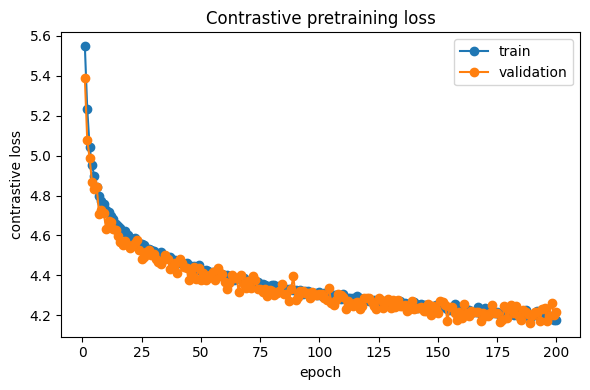

Best validation loss: 4.162352771759033
Best epoch: 189


In [23]:

# ============================================================
# Training configuration
# ============================================================

h_dim = 128
z_dim = 3

NUM_EPOCHS = 200
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
TEMPERATURE = 0.1

PRINT_EVERY = 50

CHECKPOINT_PATH = Path("./checkpoints/simclr_cifar10_smallcnn_best.pt")


# ============================================================
# Initialize fresh model
# ============================================================

model = SimCLRModel(h_dim=h_dim, z_dim=z_dim).to(device)


# ============================================================
# Train model
# ============================================================

model, history, checkpoint = train_contrastive_model(
    model=model,
    train_loader=pretrain_train_loader,
    val_loader=pretrain_val_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    temperature=TEMPERATURE,
    device=device,
    checkpoint_path=CHECKPOINT_PATH,
    print_every=PRINT_EVERY,
)


# ============================================================
# Plot losses
# ============================================================

plot_contrastive_losses(history)

print("Best validation loss:", checkpoint["best_val_loss"])
print("Best epoch:", checkpoint["epoch"])

# 13. Visualize learned representations

After contrastive training, we can inspect how the learned representations organize CIFAR-10 images.

We extract two spaces:

$$
h = f_\theta(x)
$$

the encoder representation that we keep, and

$$
z = g_\phi(h)
$$

the projection used for contrastive loss.

Since the contrastive loss uses cosine similarity, we also normalize the embeddings before visualization:

$$
\bar{h} = \frac{h}{\|h\|_2}
$$

$$
\bar{z} = \frac{z}{\|z\|_2}
$$

Then we project the embeddings to 2D using PCA.

Labels are used only for visualization.  
They were not used during contrastive training.

The main comparison is:

- \(h\): downstream representation
- \(z\): contrastive projection space

Usually, \(h\) is the representation we keep after training.

H_test shape: (10000, 128)
Z_test shape: (10000, 3)
y_test shape: (10000,)
Mean norm of raw H: 14.839185
Mean norm of normalized H: 1.0
Mean norm of raw Z: 35.714058
Mean norm of normalized Z: 1.0
PCA explained variance for normalized H: [0.38440663 0.24977483]
PCA explained variance for normalized Z: [0.3993218  0.30764836]


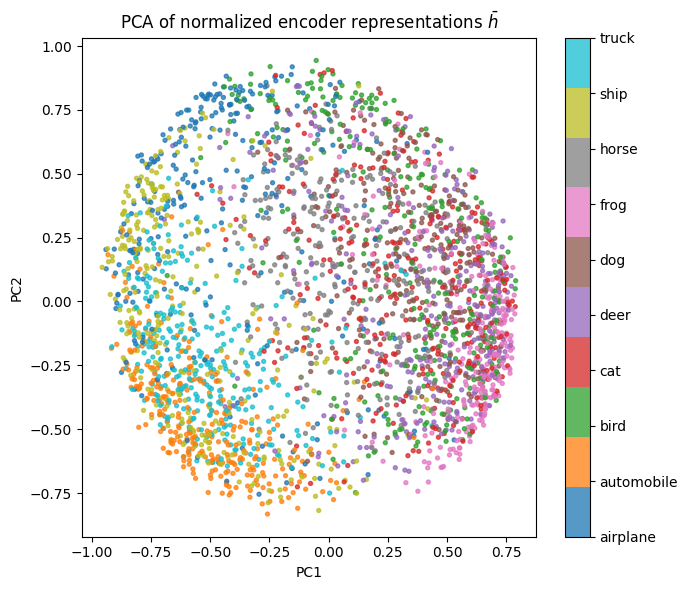

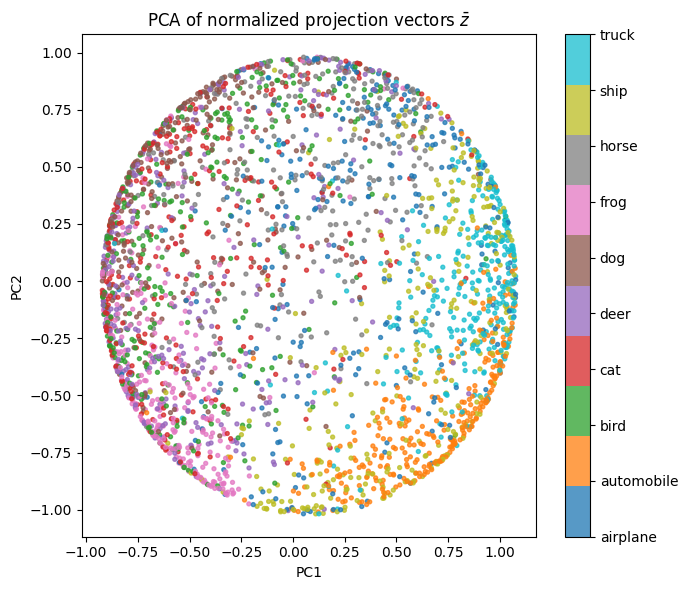

In [24]:
# ============================================================
# 13. Visualize learned representations h and z
# ============================================================

from sklearn.decomposition import PCA


@torch.no_grad()
def extract_h_z_representations(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
):
    """
    Extract encoder representations h and projection vectors z.

    Inputs:
        model:
            SimCLRModel with encoder f_theta and projector g_phi

        loader:
            deterministic evaluation DataLoader.
            It should return (x, y), not augmented views.

        device:
            torch device

    Outputs:
        H:
            encoder representations, shape [N, h_dim]

        Z:
            projection vectors, shape [N, z_dim]

        y:
            labels, shape [N]
    """

    model.eval()

    all_h = []
    all_z = []
    all_y = []

    for x, y in loader:
        x = x.to(device)

        h, z = model(x)

        all_h.append(h.cpu())
        all_z.append(z.cpu())
        all_y.append(y.cpu())

    H = torch.cat(all_h, dim=0).numpy()
    Z = torch.cat(all_z, dim=0).numpy()
    y = torch.cat(all_y, dim=0).numpy()

    return H, Z, y


def l2_normalize_numpy(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """
    L2-normalize rows of a numpy array.

    Input:
        X: [N, D]

    Output:
        X_norm: [N, D]
    """

    norms = np.linalg.norm(X, axis=1, keepdims=True)
    X_norm = X / (norms + eps)

    return X_norm


def pca_2d(X: np.ndarray, random_state: int = 7):
    """
    Project features to 2D using PCA.

    Input:
        X: [N, D]

    Output:
        X_2d: [N, 2]
        pca: fitted PCA object
    """

    pca = PCA(n_components=2, random_state=random_state)
    X_2d = pca.fit_transform(X)

    return X_2d, pca


def plot_2d_embeddings(
    X_2d: np.ndarray,
    y: np.ndarray,
    class_names,
    title: str,
    max_points: int = 3000,
    seed: int = 7,
):
    """
    Plot 2D embeddings colored by class label.
    """

    rng = np.random.default_rng(seed)

    n = X_2d.shape[0]

    if n > max_points:
        idx = rng.choice(n, size=max_points, replace=False)
        X_plot = X_2d[idx]
        y_plot = y[idx]
    else:
        X_plot = X_2d
        y_plot = y

    plt.figure(figsize=(7, 6))

    scatter = plt.scatter(
        X_plot[:, 0],
        X_plot[:, 1],
        c=y_plot,
        s=8,
        alpha=0.75,
        cmap="tab10",
    )

    cbar = plt.colorbar(scatter, ticks=np.arange(len(class_names)))
    cbar.ax.set_yticklabels(class_names)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Extract h and z from the downstream test set
# ------------------------------------------------------------

H_test, Z_test, y_test = extract_h_z_representations(
    model=model,
    loader=downstream_test_loader,
    device=device,
)

print("H_test shape:", H_test.shape)
print("Z_test shape:", Z_test.shape)
print("y_test shape:", y_test.shape)


# ------------------------------------------------------------
# Normalize because the contrastive loss uses cosine similarity
# ------------------------------------------------------------

H_test_norm = l2_normalize_numpy(H_test)
Z_test_norm = l2_normalize_numpy(Z_test)

print("Mean norm of raw H:", np.mean(np.linalg.norm(H_test, axis=1)))
print("Mean norm of normalized H:", np.mean(np.linalg.norm(H_test_norm, axis=1)))
print("Mean norm of raw Z:", np.mean(np.linalg.norm(Z_test, axis=1)))
print("Mean norm of normalized Z:", np.mean(np.linalg.norm(Z_test_norm, axis=1)))


# ------------------------------------------------------------
# PCA visualization
# ------------------------------------------------------------

H_test_pca, pca_h = pca_2d(H_test_norm)
Z_test_pca, pca_z = pca_2d(Z_test_norm)

print("PCA explained variance for normalized H:", pca_h.explained_variance_ratio_)
print("PCA explained variance for normalized Z:", pca_z.explained_variance_ratio_)


# ------------------------------------------------------------
# Plot h-space and z-space
# ------------------------------------------------------------

class_names = test_eval_dataset.classes

plot_2d_embeddings(
    X_2d=H_test_pca,
    y=y_test,
    class_names=class_names,
    title=r"PCA of normalized encoder representations $\bar{h}$",
    max_points=3000,
)

plot_2d_embeddings(
    X_2d=Z_test_pca,
    y=y_test,
    class_names=class_names,
    title=r"PCA of normalized projection vectors $\bar{z}$",
    max_points=3000,
)

# Some Fancy 3D sphere visualization for h and z for lecture

In [38]:
# ============================================================
# Interactive Plotly sphere plot for z on S2
# With size / thickness / opacity options
# No LaTeX / MathJax strings
# ============================================================

import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "iframe_connected"


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def l2_normalize_numpy(X, eps=1e-8):
    """
    L2-normalize rows of a numpy array.
    """
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)


def make_unit_sphere_mesh(n_u=80, n_v=40):
    """
    Create unit sphere mesh for Plotly surface.
    """
    u = np.linspace(0, 2 * np.pi, n_u)
    v = np.linspace(0, np.pi, n_v)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    return x, y, z


def compute_class_centroids_on_sphere(Z_sphere, y, class_names):
    """
    Compute class centroids and project them back to the sphere.
    """
    centroids = []

    for class_id in range(len(class_names)):
        mask = y == class_id
        Z_class = Z_sphere[mask]

        if len(Z_class) == 0:
            centroids.append(np.zeros(3))
            continue

        centroid = Z_class.mean(axis=0, keepdims=True)
        centroid = l2_normalize_numpy(centroid)[0]
        centroids.append(centroid)

    return np.stack(centroids, axis=0)


def downsample_indices(indices, max_points, rng):
    """
    Downsample indices if needed.
    """
    indices = np.asarray(indices)

    if len(indices) > max_points:
        return rng.choice(indices, size=max_points, replace=False)

    return indices


def add_unit_sphere_wireframe(
    fig,
    n_lat=9,
    n_lon=13,
    line_color="rgba(120,120,120,0.35)",
    line_width=1.0,
    visible=True,
):
    """
    Add sphere latitude/longitude wireframe as Scatter3d line traces.

    Returns:
        wire_trace_indices: list of trace indices
    """

    wire_trace_indices = []

    # Longitude lines
    theta = np.linspace(0, np.pi, 120)
    for phi in np.linspace(0, 2 * np.pi, n_lon, endpoint=False):
        x = np.sin(theta) * np.cos(phi)
        y = np.sin(theta) * np.sin(phi)
        z = np.cos(theta)

        trace_idx = len(fig.data)
        wire_trace_indices.append(trace_idx)

        fig.add_trace(
            go.Scatter3d(
                x=x,
                y=y,
                z=z,
                mode="lines",
                line=dict(
                    color=line_color,
                    width=line_width,
                ),
                hoverinfo="skip",
                showlegend=False,
                visible=visible,
            )
        )

    # Latitude lines
    phi = np.linspace(0, 2 * np.pi, 160)
    for theta0 in np.linspace(0.15 * np.pi, 0.85 * np.pi, n_lat):
        x = np.sin(theta0) * np.cos(phi)
        y = np.sin(theta0) * np.sin(phi)
        z = np.full_like(phi, np.cos(theta0))

        trace_idx = len(fig.data)
        wire_trace_indices.append(trace_idx)

        fig.add_trace(
            go.Scatter3d(
                x=x,
                y=y,
                z=z,
                mode="lines",
                line=dict(
                    color=line_color,
                    width=line_width,
                ),
                hoverinfo="skip",
                showlegend=False,
                visible=visible,
            )
        )

    return wire_trace_indices


# ------------------------------------------------------------
# Main interactive plot
# ------------------------------------------------------------

def plot_interactive_z_sphere(
    Z,
    y,
    class_names,
    max_points_per_class=700,
    max_points_rest=3500,
    seed=7,
    title="Interactive contrastive projection space: z_bar on S2",
    width=1000,
    height=820,

    # -----------------------------
    # Point size options
    # -----------------------------
    size_all_points=3.5,
    size_rest_points=2.5,
    size_selected_points=5.0,
    size_centroid_all=10,
    size_centroid_selected=12,

    # -----------------------------
    # Point opacity options
    # -----------------------------
    opacity_all_points=0.78,
    opacity_rest_points=0.20,
    opacity_selected_points=0.92,
    opacity_centroid_all=0.95,
    opacity_centroid_selected=1.0,

    # -----------------------------
    # Centroid marker border options
    # -----------------------------
    centroid_all_line_width=0.8,
    centroid_selected_line_width=1.4,
    centroid_line_color="black",

    # -----------------------------
    # Sphere options
    # -----------------------------
    show_sphere_surface=True,
    sphere_surface_opacity=0.10,
    sphere_surface_color="rgb(230,230,230)",

    show_sphere_wireframe=True,
    sphere_wire_width=1.0,
    sphere_wire_color='black',#"rgba(120,120,120,0.35)",
    sphere_n_lat=9,
    sphere_n_lon=13,

    # -----------------------------
    # Axis/grid thickness options
    # -----------------------------
    axis_line_width=2,
    grid_line_width=1,
    zero_line_width=2,

    # -----------------------------
    # Colors
    # -----------------------------
    rest_color="lightgray",
    selected_color="royalblue",
    selected_centroid_color="navy",
    all_centroid_color="black",

    # -----------------------------
    # Camera
    # -----------------------------
    camera_eye=(1.45, 1.45, 1.15),
):
    """
    Interactive Plotly visualization of z on the unit sphere.

    Default view:
        all classes shown together with different colors

    Dropdown views:
        selected class shown in blue
        all other samples shown in gray

    Inputs:
        Z:
            [N, 3] raw z vectors

        y:
            [N] integer class labels

        class_names:
            list of class names
    """

    assert Z.shape[1] == 3, f"Expected Z with shape [N, 3], got {Z.shape}"

    rng = np.random.default_rng(seed)

    # Normalize z onto S2.
    Z_sphere = l2_normalize_numpy(Z)

    n_classes = len(class_names)

    class_colors = [
        "#1f77b4",  # blue
        "#ff7f0e",  # orange
        "#2ca02c",  # green
        "#d62728",  # red
        "#9467bd",  # purple
        "#8c564b",  # brown
        "#e377c2",  # pink
        "#7f7f7f",  # gray
        "#bcbd22",  # olive
        "#17becf",  # cyan
    ]

    fig = go.Figure()

    always_visible_trace_indices = []

    # --------------------------------------------------------
    # Unit sphere surface
    # --------------------------------------------------------

    if show_sphere_surface:
        sx, sy, sz = make_unit_sphere_mesh()

        sphere_surface_trace_idx = len(fig.data)
        always_visible_trace_indices.append(sphere_surface_trace_idx)

        fig.add_trace(
            go.Surface(
                x=sx,
                y=sy,
                z=sz,
                opacity=sphere_surface_opacity,
                showscale=False,
                colorscale=[[0, sphere_surface_color], [1, sphere_surface_color]],
                hoverinfo="skip",
                name="unit sphere surface",
                visible=True,
            )
        )

    # --------------------------------------------------------
    # Unit sphere wireframe
    # --------------------------------------------------------

    if show_sphere_wireframe:
        wire_indices = add_unit_sphere_wireframe(
            fig=fig,
            n_lat=sphere_n_lat,
            n_lon=sphere_n_lon,
            line_color=sphere_wire_color,
            line_width=sphere_wire_width,
            visible=True,
        )
        always_visible_trace_indices.extend(wire_indices)

    # --------------------------------------------------------
    # All-class colored traces
    # --------------------------------------------------------

    all_class_trace_indices = []

    for class_id, class_name in enumerate(class_names):
        class_indices = np.where(y == class_id)[0]

        class_indices = downsample_indices(
            indices=class_indices,
            max_points=max_points_per_class,
            rng=rng,
        )

        pts = Z_sphere[class_indices]

        trace_idx = len(fig.data)
        all_class_trace_indices.append(trace_idx)

        fig.add_trace(
            go.Scatter3d(
                x=pts[:, 0],
                y=pts[:, 1],
                z=pts[:, 2],
                mode="markers",
                marker=dict(
                    size=size_all_points,
                    color=class_colors[class_id % len(class_colors)],
                    opacity=opacity_all_points,
                ),
                name=f"{class_id}: {class_name}",
                text=[class_name] * len(pts),
                hovertemplate=(
                    f"class: {class_name}<br>"
                    "z1: %{x:.3f}<br>"
                    "z2: %{y:.3f}<br>"
                    "z3: %{z:.3f}<extra></extra>"
                ),
                visible=True,
            )
        )

    # --------------------------------------------------------
    # All-class centroid trace
    # --------------------------------------------------------

    centroids = compute_class_centroids_on_sphere(
        Z_sphere=Z_sphere,
        y=y,
        class_names=class_names,
    )

    all_centroid_trace_idx = len(fig.data)

    fig.add_trace(
        go.Scatter3d(
            x=centroids[:, 0],
            y=centroids[:, 1],
            z=centroids[:, 2],
            mode="markers+text",
            marker=dict(
                size=size_centroid_all,
                color=all_centroid_color,
                symbol="diamond",
                opacity=opacity_centroid_all,
                line=dict(
                    color=centroid_line_color,
                    width=centroid_all_line_width,
                ),
            ),
            text=[str(i) for i in range(n_classes)],
            textposition="top center",
            name="class centroids",
            hovertemplate=(
                "centroid class %{text}<br>"
                "z1: %{x:.3f}<br>"
                "z2: %{y:.3f}<br>"
                "z3: %{z:.3f}<extra></extra>"
            ),
            visible=True,
        )
    )

    # --------------------------------------------------------
    # Highlight traces for dropdown
    # --------------------------------------------------------

    highlight_trace_groups = {}

    for class_id, class_name in enumerate(class_names):
        mask_class = y == class_id
        mask_rest = ~mask_class

        class_indices = np.where(mask_class)[0]
        rest_indices = np.where(mask_rest)[0]

        class_indices = downsample_indices(
            indices=class_indices,
            max_points=max_points_per_class,
            rng=rng,
        )

        rest_indices = downsample_indices(
            indices=rest_indices,
            max_points=max_points_rest,
            rng=rng,
        )

        Z_class = Z_sphere[class_indices]
        Z_rest = Z_sphere[rest_indices]
        centroid = centroids[class_id]

        # Other classes in gray
        rest_trace_idx = len(fig.data)

        fig.add_trace(
            go.Scatter3d(
                x=Z_rest[:, 0],
                y=Z_rest[:, 1],
                z=Z_rest[:, 2],
                mode="markers",
                marker=dict(
                    size=size_rest_points,
                    color=rest_color,
                    opacity=opacity_rest_points,
                ),
                name="other classes",
                hoverinfo="skip",
                visible=False,
                showlegend=False,
            )
        )

        # Selected class in blue
        selected_trace_idx = len(fig.data)

        fig.add_trace(
            go.Scatter3d(
                x=Z_class[:, 0],
                y=Z_class[:, 1],
                z=Z_class[:, 2],
                mode="markers",
                marker=dict(
                    size=size_selected_points,
                    color=selected_color,
                    opacity=opacity_selected_points,
                ),
                name=f"selected: {class_name}",
                text=[class_name] * len(Z_class),
                hovertemplate=(
                    f"selected class: {class_name}<br>"
                    "z1: %{x:.3f}<br>"
                    "z2: %{y:.3f}<br>"
                    "z3: %{z:.3f}<extra></extra>"
                ),
                visible=False,
                showlegend=False,
            )
        )

        # Selected class centroid
        centroid_trace_idx = len(fig.data)

        fig.add_trace(
            go.Scatter3d(
                x=[centroid[0]],
                y=[centroid[1]],
                z=[centroid[2]],
                mode="markers+text",
                marker=dict(
                    size=size_centroid_selected,
                    color=selected_centroid_color,
                    symbol="diamond",
                    opacity=opacity_centroid_selected,
                    line=dict(
                        color=centroid_line_color,
                        width=centroid_selected_line_width,
                    ),
                ),
                text=[f"{class_id}: {class_name}"],
                textposition="top center",
                name=f"centroid: {class_name}",
                hovertemplate=(
                    f"centroid: {class_name}<br>"
                    "z1: %{x:.3f}<br>"
                    "z2: %{y:.3f}<br>"
                    "z3: %{z:.3f}<extra></extra>"
                ),
                visible=False,
                showlegend=False,
            )
        )

        highlight_trace_groups[class_id] = [
            rest_trace_idx,
            selected_trace_idx,
            centroid_trace_idx,
        ]

    # --------------------------------------------------------
    # Dropdown buttons
    # --------------------------------------------------------

    n_traces = len(fig.data)
    buttons = []

    # Button: all classes
    visible_all = [False] * n_traces

    for idx in always_visible_trace_indices:
        visible_all[idx] = True

    for idx in all_class_trace_indices:
        visible_all[idx] = True

    visible_all[all_centroid_trace_idx] = True

    buttons.append(
        dict(
            label="All classes",
            method="update",
            args=[
                {"visible": visible_all},
                {"title": title + " - all classes"},
            ],
        )
    )

    # Buttons: selected class vs rest
    for class_id, class_name in enumerate(class_names):
        visible_class = [False] * n_traces

        for idx in always_visible_trace_indices:
            visible_class[idx] = True

        for idx in highlight_trace_groups[class_id]:
            visible_class[idx] = True

        buttons.append(
            dict(
                label=f"{class_id}: {class_name}",
                method="update",
                args=[
                    {"visible": visible_class},
                    {"title": title + f" - selected class: {class_name}"},
                ],
            )
        )

    # --------------------------------------------------------
    # Layout
    # --------------------------------------------------------

    cam_x, cam_y, cam_z = camera_eye

    fig.update_layout(
        title=title + " - all classes",
        width=width,
        height=height,
        template="plotly_white",
        scene=dict(
            xaxis=dict(
                title="z1",
                range=[-1.05, 1.05],
                showbackground=False,
                showgrid=True,
                gridwidth=grid_line_width,
                zeroline=True,
                zerolinewidth=zero_line_width,
                showline=True,
                linewidth=axis_line_width,
            ),
            yaxis=dict(
                title="z2",
                range=[-1.05, 1.05],
                showbackground=False,
                showgrid=True,
                gridwidth=grid_line_width,
                zeroline=True,
                zerolinewidth=zero_line_width,
                showline=True,
                linewidth=axis_line_width,
            ),
            zaxis=dict(
                title="z3",
                range=[-1.05, 1.05],
                showbackground=False,
                showgrid=True,
                gridwidth=grid_line_width,
                zeroline=True,
                zerolinewidth=zero_line_width,
                showline=True,
                linewidth=axis_line_width,
            ),
            aspectmode="cube",
            camera=dict(
                eye=dict(x=cam_x, y=cam_y, z=cam_z)
            ),
        ),
        legend=dict(
            x=1.02,
            y=0.95,
            bgcolor="rgba(255,255,255,0)",
        ),
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                showactive=True,
                x=0.02,
                y=1.08,
                xanchor="left",
                yanchor="top",
            )
        ],
        margin=dict(l=0, r=0, b=0, t=85),
    )

    fig.show()

    return fig

In [43]:
fig_z_interactive = plot_interactive_z_sphere(
    Z=Z_test,
    y=y_test,
    class_names=class_names,
    max_points_per_class=27000,
    max_points_rest=35000,
    title="Interactive contrastive projection space: z_bar on S2",

    size_all_points=4,
    size_rest_points=2,
    size_selected_points=8,
    size_centroid_all=1,
    size_centroid_selected=16,

    sphere_wire_width=2.0,
    sphere_surface_opacity=0.98,

    centroid_selected_line_width=2.0,
    axis_line_width=2,
    grid_line_width=2,
)